# Notebook 3 — Clinical Analyses

This notebook investigates cross-sectional associations between brain age
estimates and clinical variables in the OFAMS cohort at baseline. All
regression analyses control for chronological age, sex, and disease duration
as covariates, following the approach recommended by de Lange & Cole (2020).

## Contents

**3.1 Setup**
Imports, plot style, and model color conventions. Master dataframes produced
by Notebook 1 are loaded and baseline subsets extracted.

**3.2 Exploratory plots**
Distribution of disease duration and its relationship with chronological age,
used to characterize the clinical sample before formal analyses.

**3.3 Brain age vs. disease duration**
Partial regression analysis (OLS) of predicted brain age against disease
duration, controlling for age and sex. Results are visualized as added
variable plots.

**3.4 Brain age vs. EDSS**
Partial regression analysis of predicted brain age against EDSS score,
controlling for age, sex, and disease duration.

**3.5 Brain age vs. fatigue**
Partial regression analysis of predicted brain age against fatigue score,
controlling for age, sex, and disease duration.

**3.6 Clinical correlation heatmap**
Spearman rank correlation matrix between brain age estimates and all clinical
variables at baseline, visualized as a lower-triangle heatmap. Spearman
correlation is used throughout as EDSS is ordinal and clinical variables
are not guaranteed to be normally distributed.




## 3.1 Setup

Imports and plot style. Master dataframes produced by Notebook 1 are loaded,
and baseline subsets are extracted for cross-sectional analyses.

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pingouin as pg   # pip install pingouin  (for ICC)
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)

# Consistent model colors across all figures
COLORS = {
    'pyment':    '#7B4FA6',
    'brainageR': '#3A8A4A',
    'HBA':       '#D94F4F'
}

In [4]:
# Load master dataframes produced by Notebook 1
pyment = pd.read_csv("clean_pyment.csv")
bar    = pd.read_csv("clean_brainageR.csv")
hba    = pd.read_csv("clean_hba.csv")

In [5]:
# Extract baseline-rows (cross-sectional analysis)
bl_pyment = pyment[pyment['session'] == 'baseline'].copy()
bl_bar    = bar[bar['session']       == 'baseline'].copy()
bl_hba    = hba[hba['session']       == 'baseline'].copy()

## 3.2 Exploratory plots
Exploritory analysis of disease duration

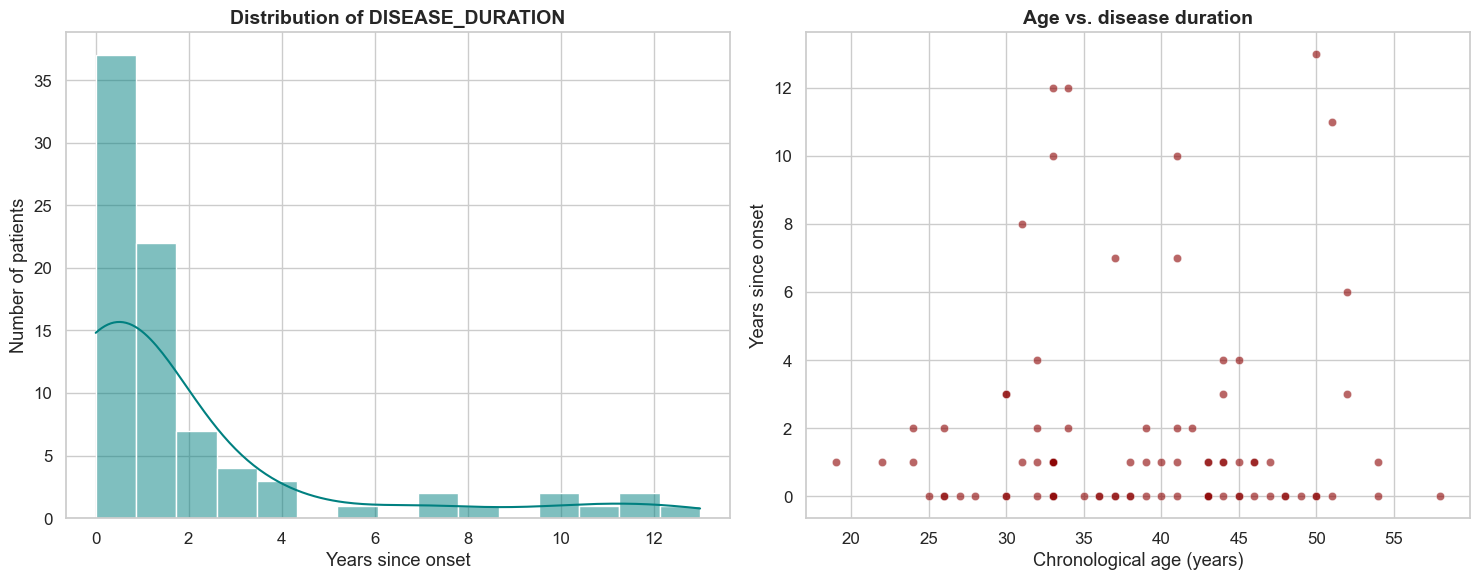

In [7]:
def plot_ms_history(df, duration_col='DISEASE_DURATION'):
    """
    Plot the distribution of disease duration and its relationship with age.

    Parameters
    ----------
    df : DataFrame
        Baseline dataframe for one model.
    duration_col : str
        Column containing disease duration in years (default: 'DISEASE_DURATION').
    """
    if duration_col not in df.columns:
        print(f"Column '{duration_col}' not found in DataFrame.")
        return

    # Drop rows with missing disease duration or age
    clean_df = df.dropna(subset=[duration_col, 'age']).copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Distribution of disease duration
    sns.histplot(data=clean_df, x=duration_col, kde=True, color='teal', ax=axes[0])
    axes[0].set_title(f'Distribution of {duration_col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Years since onset')
    axes[0].set_ylabel('Number of patients')

    # Relationship between chronological age and disease duration
    sns.scatterplot(data=clean_df, x='age', y=duration_col,
                    alpha=0.6, color='darkred', ax=axes[1])
    axes[1].set_title('Age vs. disease duration', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Chronological age (years)')
    axes[1].set_ylabel('Years since onset')

    plt.tight_layout()
    plt.show()


plot_ms_history(bl_bar)

## 3.3 Brain Age vs. Disease Duration

The association between predicted brain age and disease duration is assessed
using OLS regression (predicted_age ~ age + sex + disease_duration). The
added variable plot displays the residuals of predicted brain age after
removing the variance explained by age and sex, plotted against the
residuals of disease duration after the same adjustment. This isolates the
independent contribution of disease duration to brain age, net of the other
covariates.

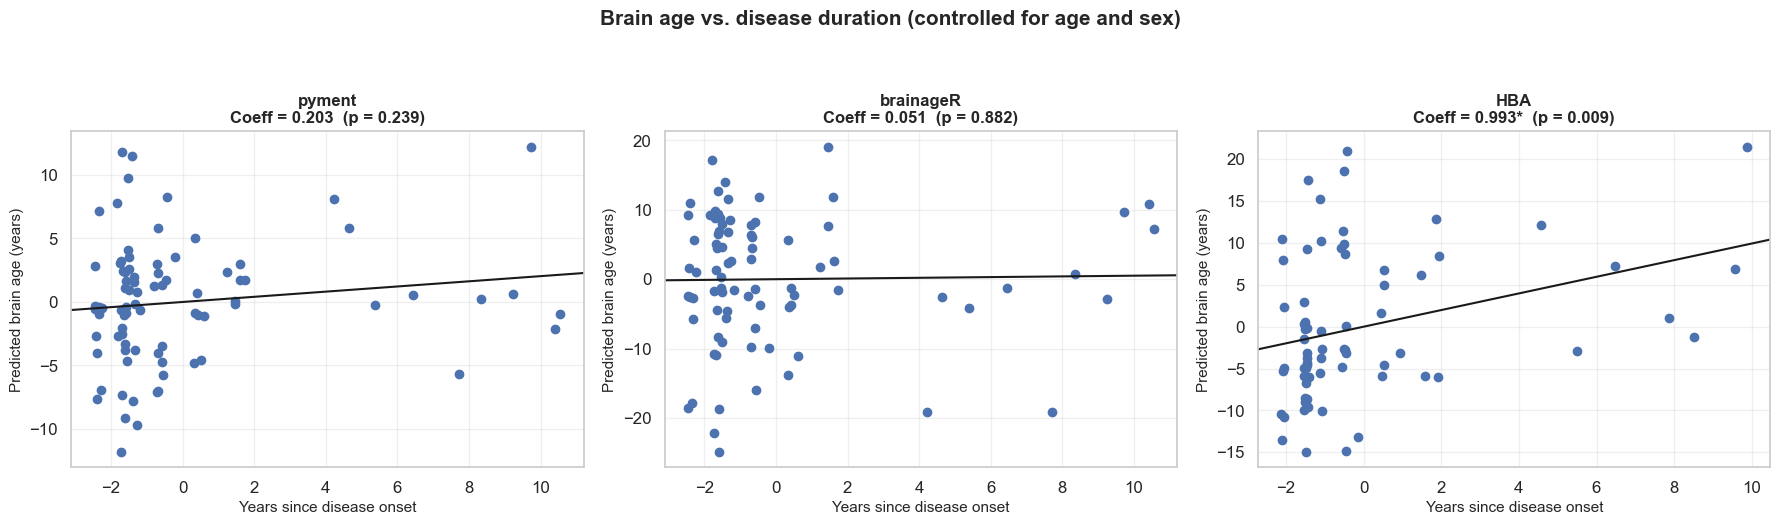

In [9]:
def plot_partial_duration(df_list, names, duration_col='DISEASE_DURATION',
                          target_col='predicted_age'):
    """
    Partial regression plot: brain age vs. disease duration, controlling for age and sex.
    Fits OLS (predicted_age ~ age + sex + disease_duration) for each model and
    displays the partial regression plot, which isolates the relationship between
    disease duration and brain age after removing the variance explained by
    age and sex.

    Parameters
    ----------
    df_list : list of DataFrame
        Baseline dataframes, one per model.
    names : list of str
        Model names corresponding to each dataframe.
    duration_col : str
        Column containing disease duration in years.
    target_col : str
        Column containing predicted brain age values.

    Returns
    -------
    dict
        Raw p-values and coefficients per model for Bonferroni correction.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    covars = ['age', 'C(sex)']
    raw_results = {}

    for ax, df, name in zip(axes, df_list, names):
        clean_df = df.dropna(subset=[duration_col, target_col, 'age', 'sex'])

        # OLS: predicted_age ~ age + sex + disease_duration
        formula = f"{target_col} ~ {' + '.join(covars)} + {duration_col}"
        model = smf.ols(formula=formula, data=clean_df).fit()

        coef  = model.params[duration_col]
        p_val = model.pvalues[duration_col]
        raw_results[name] = {'coef': coef, 'p': p_val}

        # Partial regression plot
        sm.graphics.plot_partregress(
            endog=target_col,
            exog_i=duration_col,
            exog_others=covars,
            data=clean_df,
            ax=ax,
            obs_labels=False
        )

        sig = '*' if p_val < 0.05 else ''
        ax.set_title(f'{name}\nCoeff = {coef:.3f}{sig}  (p = {p_val:.3f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Years since disease onset', fontsize=11)
        ax.set_ylabel('Predicted brain age (years)', fontsize=11)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Brain age vs. disease duration (controlled for age and sex)',
                 fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('ba_vs_diseasedur.png', dpi=200, bbox_inches='tight')
    plt.show()

    return raw_results


dd_results = plot_partial_duration(
    [bl_pyment, bl_bar, bl_hba],
    ['pyment', 'brainageR', 'HBA']
)

## 3.4 Brain age vs. EDSS

The association between predicted brain age and disability level is assessed
using OLS regression (predicted_age ~ age + sex + disease_duration +
edss_score). The added variable plot displays the residuals of predicted
brain age after removing variance explained by age, sex, and disease
duration, plotted against the residuals of EDSS after the same adjustment.
This isolates the independent contribution of disability to brain age,
net of the other covariates.

Note that EDSS is an ordinal scale and its inclusion in OLS assumes a
linear relationship with predicted brain age. Results should be interpreted
with this limitation in mind.

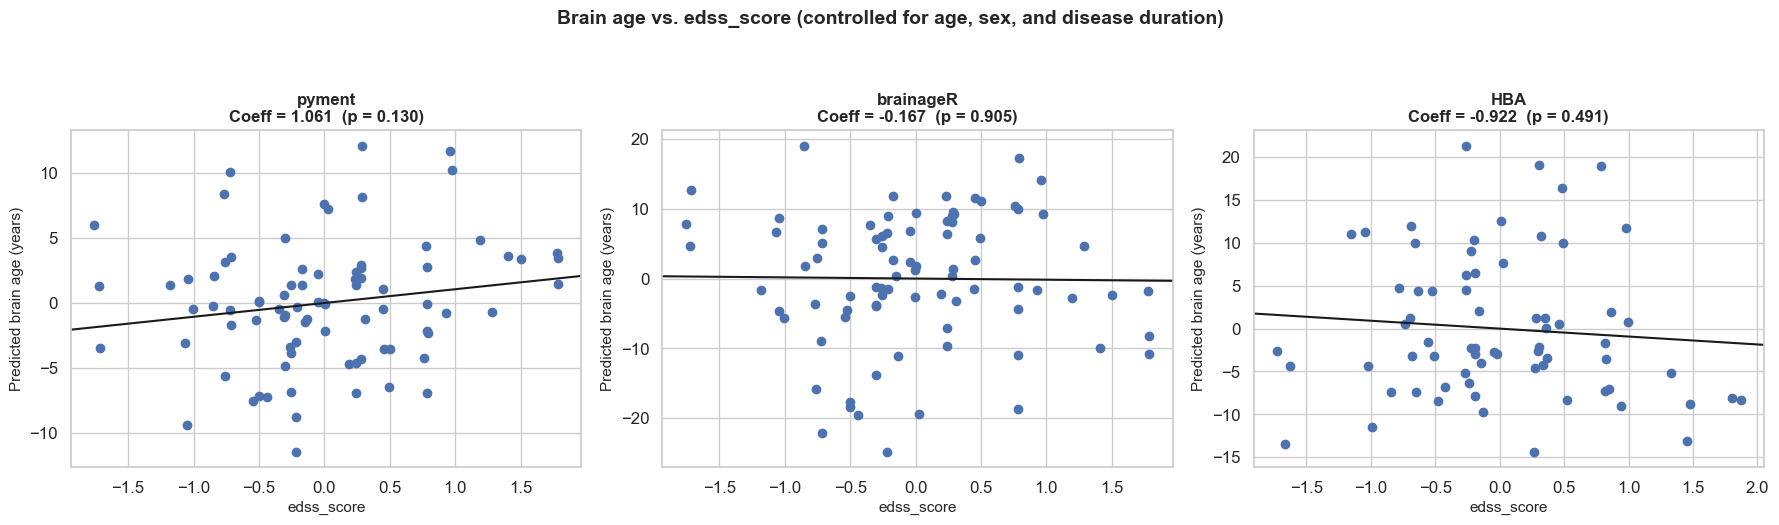

In [11]:
def analyze_and_plot_clinical(df_list, names, target_var='predicted_age',
                               clinical_var='edss_score'):
    """
    Partial regression plot: brain age vs. clinical variable, controlling
    for age, sex, and disease duration. Returns raw results for
    Bonferroni correction.
    """
    covars = ['age', 'C(sex)', 'DISEASE_DURATION']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    raw_results = {}

    for ax, df, name in zip(axes, df_list, names):
        formula  = f"{target_var} ~ {' + '.join(covars)} + {clinical_var}"
        cols_needed = [target_var, clinical_var, 'age', 'sex', 'DISEASE_DURATION']
        clean_df = df.dropna(subset=cols_needed)
        model = smf.ols(formula=formula, data=clean_df).fit()

        coef  = model.params[clinical_var]
        p_val = model.pvalues[clinical_var]
        raw_results[name] = {'coef': coef, 'p': p_val}

        sm.graphics.plot_partregress(
            endog=target_var,
            exog_i=clinical_var,
            exog_others=covars,
            data=clean_df,
            ax=ax,
            obs_labels=False
        )

        sig = '*' if p_val < 0.05 else ''
        ax.set_title(f'{name}\nCoeff = {coef:.3f}{sig}  (p = {p_val:.3f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel(clinical_var, fontsize=11)
        ax.set_ylabel('Predicted brain age (years)', fontsize=11)

    plt.suptitle(f'Brain age vs. {clinical_var} (controlled for age, sex, and disease duration)',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'ba_vs_{clinical_var}.png', dpi=200, bbox_inches='tight')
    plt.show()

    return raw_results


edss_results    = analyze_and_plot_clinical(
    [bl_pyment, bl_bar, bl_hba], ['pyment', 'brainageR', 'HBA'],
    clinical_var='edss_score'
)

## 3.5 Brain Age vs. Fatigue (FSS)

The association between predicted brain age and fatigue is assessed using
OLS regression (predicted_age ~ age + sex + disease_duration + fatigue).
The added variable plot displays the residuals of predicted brain age after
removing variance explained by age, sex, and disease duration, plotted
against the residuals of FSS score after the same adjustment. This isolates
the independent contribution of fatigue to brain age, net of the other
covariates.

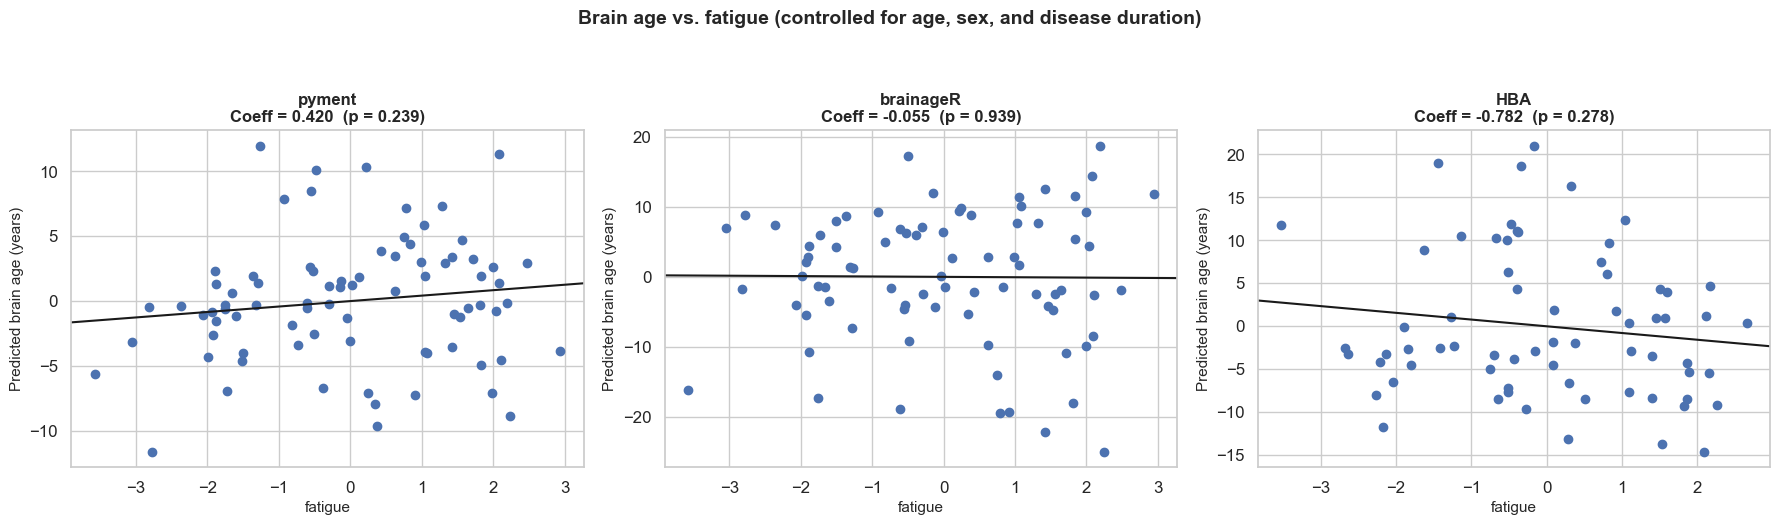

In [13]:
fatigue_results = analyze_and_plot_clinical(
    [bl_pyment, bl_bar, bl_hba], ['pyment', 'brainageR', 'HBA'],
    clinical_var='fatigue'
)

In [14]:
# ── Bonferroni correction: clinical associations (m=3 per outcome) ────────────

from statsmodels.stats.multitest import multipletests

clinical_tests = {
    'Disease duration': dd_results,
    'EDSS':             edss_results,
    'Fatigue':          fatigue_results,
}

models = ['pyment', 'brainageR', 'HBA']

print("Bonferroni correction: clinical associations (m = 3 per outcome)")
print("=" * 65)

for outcome, results in clinical_tests.items():
    p_vals = [results[name]['p'] for name in models]
    reject, p_corrected, _, alpha_corr = multipletests(
        p_vals, alpha=0.05, method='bonferroni'
    )
    print(f"\n{outcome} (corrected α = {alpha_corr:.4f})")
    print("-" * 65)
    for name, p_raw, p_corr, sig in zip(models, p_vals, p_corrected, reject):
        star = '*' if sig else 'ns'
        print(f"  {name}: coeff = {results[name]['coef']:.3f}  "
              f"p = {p_raw:.4f}  p_corr = {p_corr:.4f}  {star}")

Bonferroni correction: clinical associations (m = 3 per outcome)

Disease duration (corrected α = 0.0167)
-----------------------------------------------------------------
  pyment: coeff = 0.203  p = 0.2391  p_corr = 0.7172  ns
  brainageR: coeff = 0.051  p = 0.8820  p_corr = 1.0000  ns
  HBA: coeff = 0.993  p = 0.0091  p_corr = 0.0272  *

EDSS (corrected α = 0.0167)
-----------------------------------------------------------------
  pyment: coeff = 1.061  p = 0.1302  p_corr = 0.3907  ns
  brainageR: coeff = -0.167  p = 0.9049  p_corr = 1.0000  ns
  HBA: coeff = -0.922  p = 0.4913  p_corr = 1.0000  ns

Fatigue (corrected α = 0.0167)
-----------------------------------------------------------------
  pyment: coeff = 0.420  p = 0.2391  p_corr = 0.7173  ns
  brainageR: coeff = -0.055  p = 0.9388  p_corr = 1.0000  ns
  HBA: coeff = -0.782  p = 0.2783  p_corr = 0.8350  ns


## 3.6 Clinical correlation heatmap

Pairwise Spearman rank correlations between predicted brain age, BAG, and
all clinical variables are visualized as a lower-triangle heatmap for each
model. Spearman correlation is used throughout as EDSS is ordinal and the
clinical variables are not guaranteed to be normally distributed. The heatmap
provides an overview of the correlation structure at baseline, complementing
the targeted regression analyses in sections 3.3–3.5.

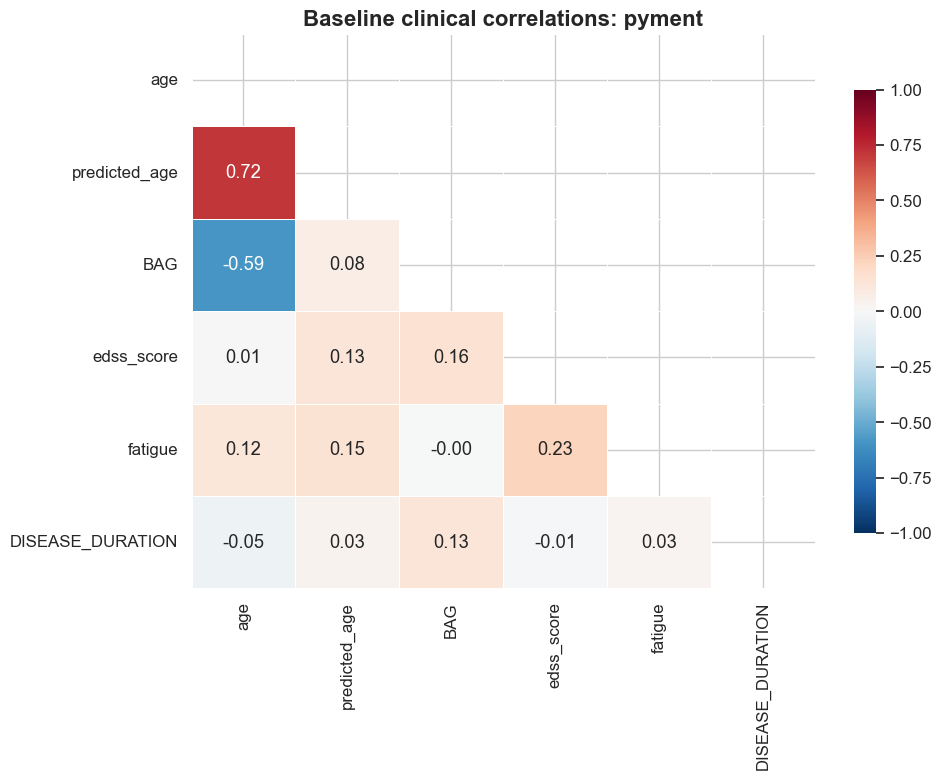

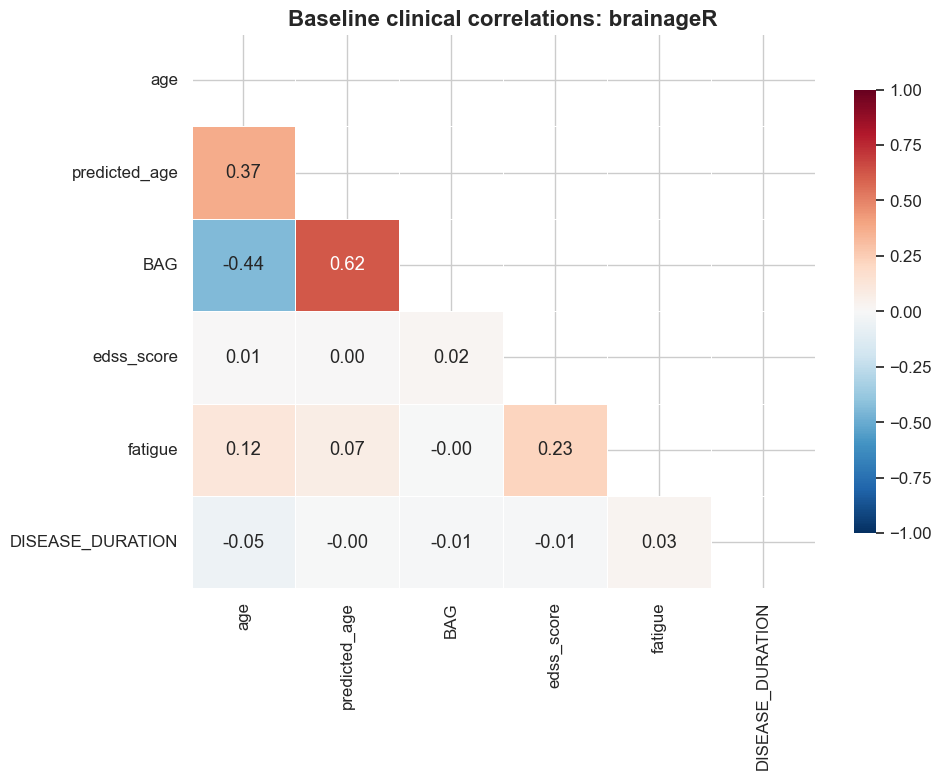

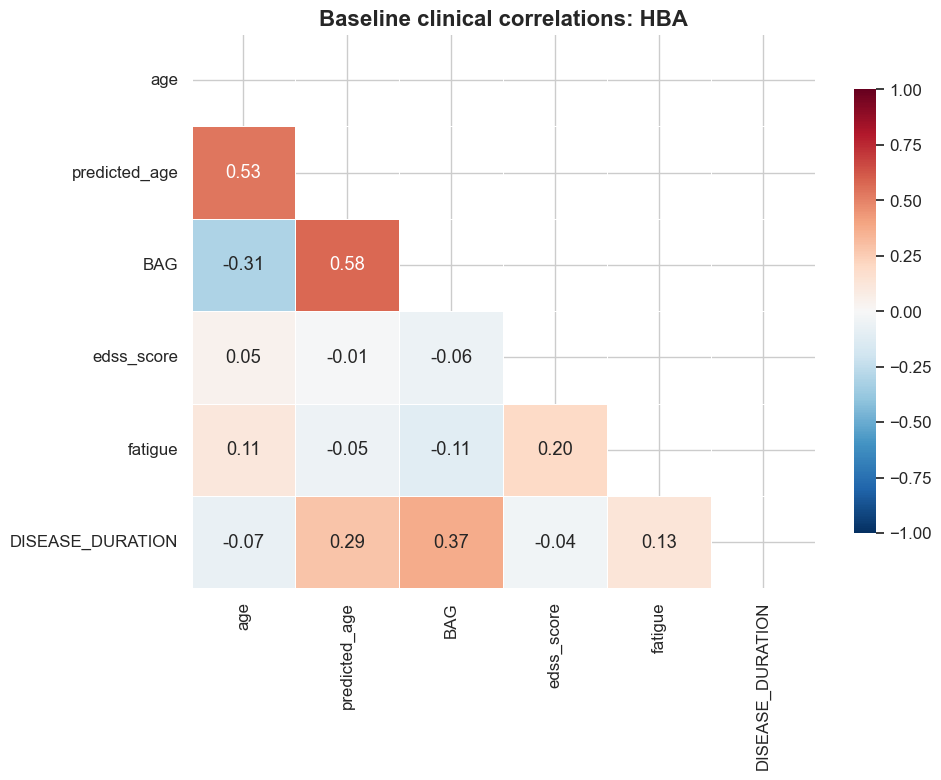

In [16]:
def plot_clinical_heatmap(df, name):
    """
    Spearman correlation heatmap between brain age and clinical variables at baseline.

    Spearman rank correlation is used throughout as EDSS is ordinal and
    clinical variables are not guaranteed to be normally distributed.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    name : str
        Model name used in the plot title.
    """
    cols = ['age', 'predicted_age', 'BAG', 'edss_score', 'fatigue', 'DISEASE_DURATION']

    # Retain only columns present in the dataframe
    available_cols = [c for c in cols if c in df.columns]

    # Subset to baseline and compute Spearman correlation matrix
    baseline_df  = df[df['session'] == 'baseline'][available_cols]
    corr_matrix  = baseline_df.corr(method='spearman')

    # Mask upper triangle to avoid redundant values
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        cmap='RdBu_r',
        center=0,
        fmt='.2f',
        linewidths=0.5,
        vmin=-1, vmax=1,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f'Baseline clinical correlations: {name}',
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'clinical_heatmap_{name}.png', dpi=200, bbox_inches='tight')
    plt.show()


plot_clinical_heatmap(pyment, 'pyment')
plot_clinical_heatmap(bar,    'brainageR')
plot_clinical_heatmap(hba,    'HBA')